Import e percorsi

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw"

METADATA_PATH = DATA_DIR / "eccdna_disease_detection_metadata.tsv"
FASTA_PATH = DATA_DIR / "eccdna_disease_detection.body.fa"

print(METADATA_PATH)
print(FASTA_PATH)

print("Metadata exists:", METADATA_PATH.exists())
print("FASTA exists:", FASTA_PATH.exists())

..\data\raw\eccdna_disease_detection_metadata.tsv
..\data\raw\eccdna_disease_detection.body.fa
Metadata exists: True
FASTA exists: True


Caricamento tsv

In [3]:
metadata = pd.read_csv(
    METADATA_PATH,
    sep="\t",
    low_memory=False
)

print("Shape:", metadata.shape)

Shape: (3755079, 25)


In [4]:
metadata.head()

,id,disease_binary_label,disease_binary_name,disease,chrom,start,end,length,gc,n_fraction,...,library_type,cluster_id,role,sequence_kind,sequence_fasta,sequence_body_id,sequence_circular_id,sequence_breakpoint_id,split_cluster,split_deepcircle_external
0,eccDNABase_000124402,1,disease_associated,Prostate Cancer,chr1,11080,11289,209,0.669856,0.0,...,database_annotation,c000000001,training_core,body,data/processed/eccdna_disease_detection.body.fa,eccDNABase_000124402|body,eccDNABase_000124402|circular_pad,eccDNABase_000124402|breakpoint_context,train,val
1,CircleBaseV2_002758843,0,healthy,Healthy,chr1,12639,12867,228,0.609649,0.0,...,Circle_seq,c000000002,training_core,body,data/processed/eccdna_disease_detection.body.fa,CircleBaseV2_002758843|body,CircleBaseV2_002758843|circular_pad,CircleBaseV2_002758843|breakpoint_context,train,train
2,eccDNABase_000575011,0,healthy,Health,chr1,12640,12867,227,0.607930,0.0,...,database_annotation,c000000002,training_core,body,data/processed/eccdna_disease_detection.body.fa,eccDNABase_000575011|body,eccDNABase_000575011|circular_pad,eccDNABase_000575011|breakpoint_context,train,train
3,CircleBaseV2_000063599,1,disease_associated,Gastric cancer,chr1,13277,13961,684,0.576023,0.0,...,Circle_seq,c000000003,training_core,body,data/processed/eccdna_disease_detection.body.fa,CircleBaseV2_000063599|body,CircleBaseV2_000063599|circular_pad,CircleBaseV2_000063599|breakpoint_context,train,train
4,eccDNABase_000124403,1,disease_associated,Prostate Cancer,chr1,13536,13929,393,0.557252,0.0,...,database_annotation,c000000003,training_core,body,data/processed/eccdna_disease_detection.body.fa,eccDNABase_000124403|body,eccDNABase_000124403|circular_pad,eccDNABase_000124403|breakpoint_context,train,train


In [5]:
metadata.columns.tolist()

['id',
 'disease_binary_label',
 'disease_binary_name',
 'disease',
 'chrom',
 'start',
 'end',
 'length',
 'gc',
 'n_fraction',
 'source_db',
 'sample',
 'tissue',
 'cell_line',
 'method',
 'library_type',
 'cluster_id',
 'role',
 'sequence_kind',
 'sequence_fasta',
 'sequence_body_id',
 'sequence_circular_id',
 'sequence_breakpoint_id',
 'split_cluster',
 'split_deepcircle_external']

Informazioni generali

In [6]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755079 entries, 0 to 3755078
Data columns (total 25 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   id                         str    
 1   disease_binary_label       int64  
 2   disease_binary_name        str    
 3   disease                    str    
 4   chrom                      str    
 5   start                      int64  
 6   end                        int64  
 7   length                     int64  
 8   gc                         float64
 9   n_fraction                 float64
 10  source_db                  str    
 11  sample                     float64
 12  tissue                     str    
 13  cell_line                  str    
 14  method                     str    
 15  library_type               str    
 16  cluster_id                 str    
 17  role                       str    
 18  sequence_kind              str    
 19  sequence_fasta             str    
 20  sequence_body

In [7]:
print(f"Numero totale record: {len(metadata):,}")
print(f"Numero colonne: {metadata.shape[1]}")
print(f"ID unici: {metadata['id'].nunique():,}")

Numero totale record: 3,755,079
Numero colonne: 25
ID unici: 3,755,079


In [8]:
duplicate_ids = metadata["id"].duplicated().sum()

print(f"ID duplicati: {duplicate_ids:,}")

ID duplicati: 0


Prima analisi del target binario

In [9]:
binary_counts = metadata["disease_binary_label"].value_counts(dropna=False)

binary_counts

disease_binary_label
1    3309941
0     445138
Name: count, dtype: int64

In [10]:
binary_percentages = (
    metadata["disease_binary_label"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

binary_percentages

disease_binary_label
1    88.145709
0    11.854291
Name: proportion, dtype: float64

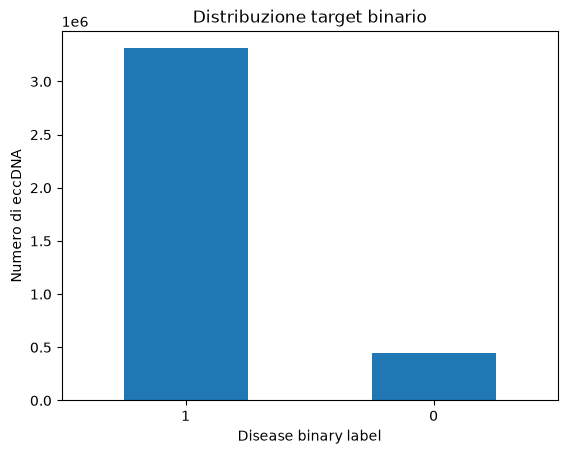

In [11]:
binary_counts.plot(kind="bar")

plt.title("Distribuzione target binario")
plt.xlabel("Disease binary label")
plt.ylabel("Numero di eccDNA")
plt.xticks(rotation=0)

plt.show()

Analisi delle varie disease

In [12]:
n_diseases = metadata["disease"].nunique(dropna=True)

print("Numero disease distinte:", n_diseases)

Numero disease distinte: 73


In [13]:
disease_counts = metadata["disease"].value_counts()

disease_counts.head(20)

disease
Gastric cancer                            2539762
Health                                     223896
Healthy                                    221242
Ovarian Cancer                             172434
Prostate Cancer                            155851
Colorectal cancer                           86914
Lymphoma                                    69245
Multiple Diseases                           57482
HIV Infectious Disease                      42923
Cervical Adenocarcinoma                     38740
Stomach Cancer                              26834
Stomach                                     26695
Leukemia                                    24304
Prostate cancer                             14446
Primary Pulmonary Hypertension               8119
Cataract                                     8021
hypopharyngeal squamous cell carcinoma       5925
Glioblastoma                                 4878
Melanoma                                     4787
Dilated Cardiomyopathy                    

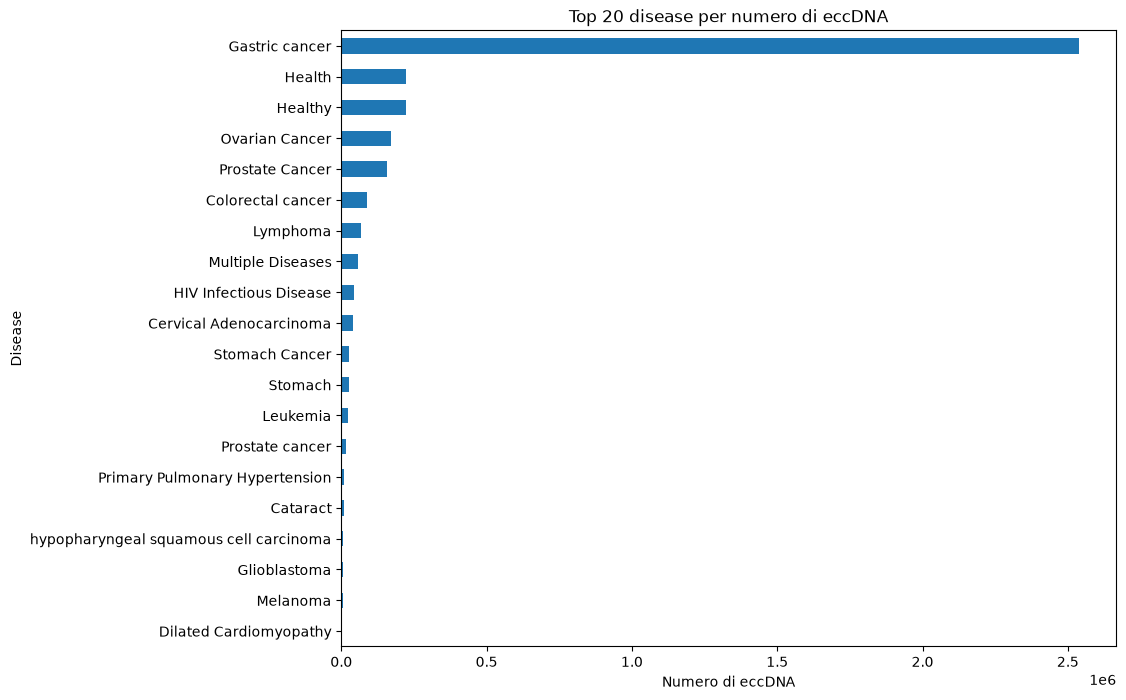

In [14]:
disease_counts.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 20 disease per numero di eccDNA")
plt.xlabel("Numero di eccDNA")
plt.ylabel("Disease")

plt.show()

Analisi delle lunghezze

In [15]:
metadata["length"].describe()

count    3.755079e+06
mean     1.582927e+03
std      7.746483e+03
min      5.000000e+01
25%      3.810000e+02
50%      7.180000e+02
75%      1.124000e+03
max      1.999980e+05
Name: length, dtype: float64

In [16]:
print("Lunghezza minima:", metadata["length"].min())
print("Lunghezza massima:", metadata["length"].max())
print("Lunghezza mediana:", metadata["length"].median())
print("Lunghezza media:", metadata["length"].mean())

Lunghezza minima: 50
Lunghezza massima: 199998
Lunghezza mediana: 718.0
Lunghezza media: 1582.9265456199457


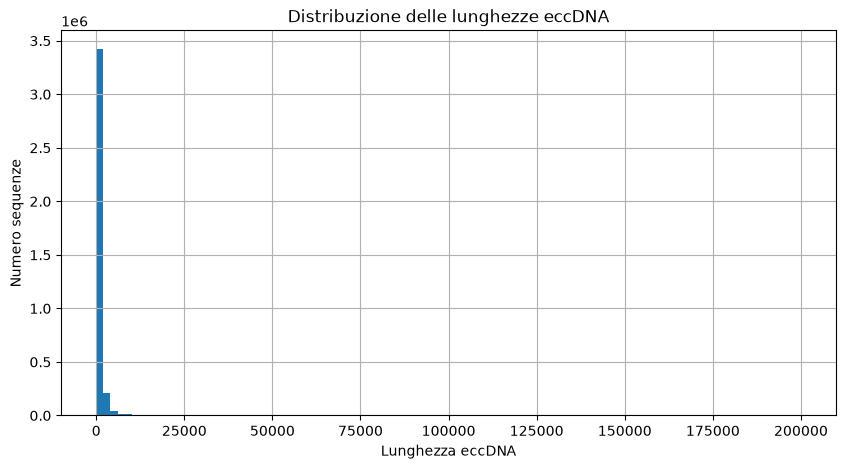

In [17]:
metadata["length"].hist(
    bins=100,
    figsize=(10, 5)
)

plt.xlabel("Lunghezza eccDNA")
plt.ylabel("Numero sequenze")
plt.title("Distribuzione delle lunghezze eccDNA")

plt.show()

Per k-mer = 10 una sequenza deve avere almeno: 10 nucleotidi. Sequenze valide:

In [18]:
# Verifica quante sequenze sono abbastanza lunghe
# per costruire k-mer con k compreso tra 4 e 10.

for k in range(4, 11):

    valid = (metadata["length"] >= k).sum()
    percentage = valid / len(metadata) * 100

    print(
        f"k={k}: "
        f"{valid:,} sequenze utilizzabili "
        f"({percentage:.2f}%)"
    )

k=4: 3,755,079 sequenze utilizzabili (100.00%)
k=5: 3,755,079 sequenze utilizzabili (100.00%)
k=6: 3,755,079 sequenze utilizzabili (100.00%)
k=7: 3,755,079 sequenze utilizzabili (100.00%)
k=8: 3,755,079 sequenze utilizzabili (100.00%)
k=9: 3,755,079 sequenze utilizzabili (100.00%)
k=10: 3,755,079 sequenze utilizzabili (100.00%)


Numero teorico di k-mer per sequenza lunga L: numero k-mer = L - k + 1

In [19]:
metadata["n_kmers_k10"] = (
    metadata["length"] - 10 + 1
).clip(lower=0)

In [20]:
metadata["n_kmers_k10"].describe()

count    3.755079e+06
mean     1.573927e+03
std      7.746483e+03
min      4.100000e+01
25%      3.720000e+02
50%      7.090000e+02
75%      1.115000e+03
max      1.999890e+05
Name: n_kmers_k10, dtype: float64

analisi gc

In [21]:
metadata["gc"].describe()

count    3.755079e+06
mean     4.446368e-01
std      8.009760e-02
min      0.000000e+00
25%      3.870968e-01
50%      4.372694e-01
75%      4.959217e-01
max      9.900000e-01
Name: gc, dtype: float64

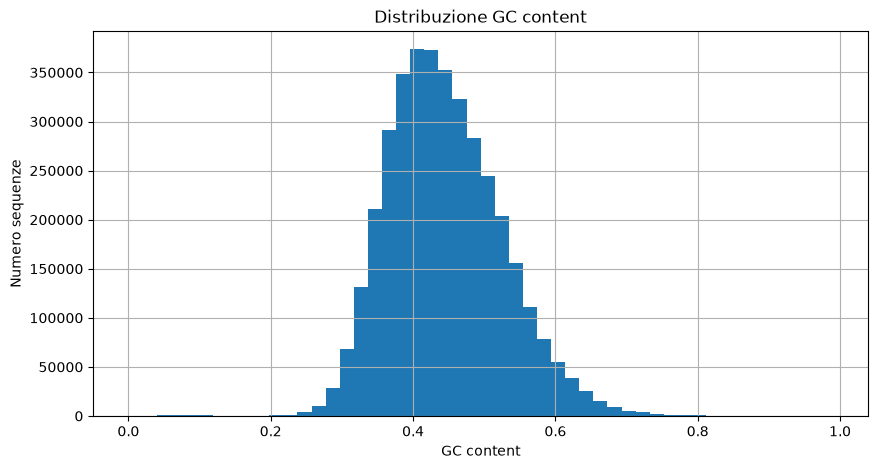

In [22]:
metadata["gc"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.xlabel("GC content")
plt.ylabel("Numero sequenze")
plt.title("Distribuzione GC content")

plt.show()

## Analisi delle basi ambigue

La colonna `n_fraction` indica la frazione di basi ambigue nelle sequenze.

Questo controllo è importante per la successiva generazione delle FCGR, perché i k-mer contenenti caratteri diversi da A, C, G e T non possono essere rappresentati normalmente nella matrice FCGR.

In [23]:
# Statistiche sulla frazione di basi ambigue

metadata["n_fraction"].describe()

count    3.755079e+06
mean     1.718632e-06
std      3.317032e-04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.701493e-02
Name: n_fraction, dtype: float64

In [24]:
n_with_ambiguous = (
    metadata["n_fraction"]
    .fillna(0)
    .gt(0)
    .sum()
)

percentage_with_ambiguous = (
    metadata["n_fraction"]
    .fillna(0)
    .gt(0)
    .mean()
    * 100
)

print(
    "Sequenze con n_fraction > 0:",
    f"{n_with_ambiguous:,}"
)

print(
    "Percentuale:",
    f"{percentage_with_ambiguous:.2f}%"
)

Sequenze con n_fraction > 0: 220
Percentuale: 0.01%


Analisi sorgenti

In [25]:
metadata["source_db"].value_counts()

source_db
CircleBaseV2    2910156
eccDNABase       844923
Name: count, dtype: int64

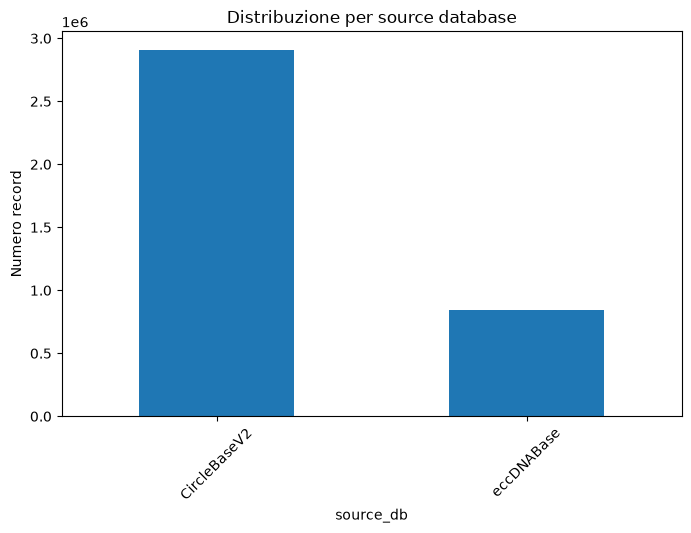

In [26]:
metadata["source_db"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribuzione per source database")
plt.ylabel("Numero record")
plt.xticks(rotation=45)

plt.show()

Analisi missing values

In [27]:
missing_values = {
    "",
    "NA",
    "NaN",
    "nan",
    "None",
    "none",
    "NULL",
    "null"
}

columns_to_check = [
    "disease",
    "tissue",
    "cell_line",
    "sample",
    "source_db",
    "split_cluster"
]

for col in columns_to_check:

    missing = (
        metadata[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .isin(missing_values)
        .sum()
    )

    percentage = missing / len(metadata) * 100

    print(
        f"{col:15s}: "
        f"{missing:,} missing "
        f"({percentage:.2f}%)"
    )

disease        : 0 missing (0.00%)
tissue         : 34,474 missing (0.92%)
cell_line      : 3,744,794 missing (99.73%)
sample         : 3,755,079 missing (100.00%)
source_db      : 0 missing (0.00%)
split_cluster  : 0 missing (0.00%)


Controllo split

In [28]:
metadata["split_cluster"].value_counts(dropna=False)

split_cluster
train    3205718
val       364756
test      184605
Name: count, dtype: int64

### Controllo dell'indipendenza dei cluster tra train, validation e test

Lo split `split_cluster` fornito con il dataset viene mantenuto per evitare di introdurre leakage tra campioni appartenenti allo stesso cluster.

Verifichiamo quindi che uno stesso `cluster_id` non compaia in più split differenti.

In [29]:
cluster_split_check = (
    metadata
    .groupby("cluster_id")["split_cluster"]
    .nunique()
)

leaky_clusters = cluster_split_check[
    cluster_split_check > 1
]

print(
    "Cluster presenti in più di uno split:",
    len(leaky_clusters)
)

Cluster presenti in più di uno split: 0


In [30]:
metadata.groupby(
    ["split_cluster", "disease_binary_label"]
).size()

split_cluster  disease_binary_label
test           0                         20852
               1                        163753
train          0                        381143
               1                       2824575
val            0                         43143
               1                        321613
dtype: int64

Guardiamo pochi esempi di FASTA

In [31]:
def read_first_fasta_records(path, n=5):

    records = []

    current_header = None
    sequence_chunks = []

    with open(path) as handle:

        for line in handle:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if current_header is not None:

                    records.append(
                        (
                            current_header,
                            "".join(sequence_chunks)
                        )
                    )

                    if len(records) >= n:
                        break

                current_header = line[1:]
                sequence_chunks = []

            else:
                sequence_chunks.append(line)

    return records

In [32]:
examples = read_first_fasta_records(
    FASTA_PATH,
    n=5
)

for header, sequence in examples:

    print("HEADER:")
    print(header)

    print("SEQUENCE LENGTH:")
    print(len(sequence))

    print("FIRST 100 NT:")
    print(sequence[:100])

    print("-" * 80)

HEADER:
eccDNABase_000124402|label=1|chrom=chr1|start=11080|end=11289|source=eccDNABase|cluster=c000000001|type=body
SEQUENCE LENGTH:
209
FIRST 100 NT:
GCGCCGTGCACGCGCAGAAACTCACGTCACGGTGGCGCGGCGCAGAGACGGGTAGAACCTCAGTAATCCGAAAAGCCGGGATCGACCGCCCCTTGCTTGC
--------------------------------------------------------------------------------
HEADER:
CircleBaseV2_002758843|label=1|chrom=chr1|start=12639|end=12867|source=CircleBaseV2|cluster=c000000002|type=body
SEQUENCE LENGTH:
228
FIRST 100 NT:
CCCCAGCATCAGGTCTCCAGAGCTGCAGAAGACGACGGCCGACTTGGATCACACTCTTGTGAGTGTCCCCAGTGTTGCAGAGGTGAGAGGAGAGTAGACA
--------------------------------------------------------------------------------
HEADER:
eccDNABase_000575011|label=1|chrom=chr1|start=12640|end=12867|source=eccDNABase|cluster=c000000002|type=body
SEQUENCE LENGTH:
227
FIRST 100 NT:
CCCAGCATCAGGTCTCCAGAGCTGCAGAAGACGACGGCCGACTTGGATCACACTCTTGTGAGTGTCCCCAGTGTTGCAGAGGTGAGAGGAGAGTAGACAG
---------------------------------------------------------------------------

controllo collegamento TSV e FASTA

In [33]:
for header, sequence in examples:

    fasta_id = header.split("|", 1)[0]

    match = metadata[
        metadata["id"] == fasta_id
    ]

    print("FASTA ID:", fasta_id)
    print("Presente nel TSV:", not match.empty)

    if not match.empty:

        print(
            match[
                [
                    "id",
                    "disease",
                    "disease_binary_label",
                    "length",
                    "split_cluster"
                ]
            ]
        )

    print("-" * 80)

FASTA ID: eccDNABase_000124402
Presente nel TSV: True
                     id          disease  disease_binary_label  length  \
0  eccDNABase_000124402  Prostate Cancer                     1     209   

  split_cluster  
0         train  
--------------------------------------------------------------------------------
FASTA ID: CircleBaseV2_002758843
Presente nel TSV: True
                       id  disease  disease_binary_label  length split_cluster
1  CircleBaseV2_002758843  Healthy                     0     228         train
--------------------------------------------------------------------------------
FASTA ID: eccDNABase_000575011
Presente nel TSV: True
                     id disease  disease_binary_label  length split_cluster
2  eccDNABase_000575011  Health                     0     227         train
--------------------------------------------------------------------------------
FASTA ID: CircleBaseV2_000063599
Presente nel TSV: True
                       id         disease 

# Analisi dei confondenti e definizione del subset sperimentale

disease x sorcedb per capire se le malattie sono distribuite tra CircleBaseV2 ed eccDNABase, oppure alcune disease provengono quasi interamente da una sola sorgente


In [34]:
source_disease_counts = pd.crosstab(
    metadata["disease"],
    metadata["source_db"]
)

source_disease_counts

source_db,CircleBaseV2,eccDNABase
disease,,
B-Cell Lymphoma,0,4
Biliary Tract Cancer,0,3
Brain Cancer,0,21
Branchio-Oculo-Facial Syndrome (Bofs),0,2076
Breast Cancer,0,654
...,...,...
Thyroid Cancer,0,3
Type 2 Diabetes Mellitus,25,25
Urinary Bladder Cancer,0,119


In [35]:
source_disease_pct = pd.crosstab(
    metadata["disease"],
    metadata["source_db"],
    normalize="index"
) * 100

source_disease_pct.round(2)

source_db,CircleBaseV2,eccDNABase
disease,,
B-Cell Lymphoma,0.0,100.0
Biliary Tract Cancer,0.0,100.0
Brain Cancer,0.0,100.0
Branchio-Oculo-Facial Syndrome (Bofs),0.0,100.0
Breast Cancer,0.0,100.0
...,...,...
Thyroid Cancer,0.0,100.0
Type 2 Diabetes Mellitus,50.0,50.0
Urinary Bladder Cancer,0.0,100.0


In [36]:
top_diseases = metadata["disease"].value_counts().head(20).index

source_top = source_disease_pct.loc[
    source_disease_pct.index.isin(top_diseases)
]

source_top.round(2)

source_db,CircleBaseV2,eccDNABase
disease,,
Cataract,100.00,0.00
Cervical Adenocarcinoma,0.00,100.00
Colorectal cancer,100.00,0.00
Dilated Cardiomyopathy,50.03,49.97
Gastric cancer,100.00,0.00
Glioblastoma,0.00,100.00
HIV Infectious Disease,0.00,100.00
Health,0.00,100.00
Healthy,100.00,0.00


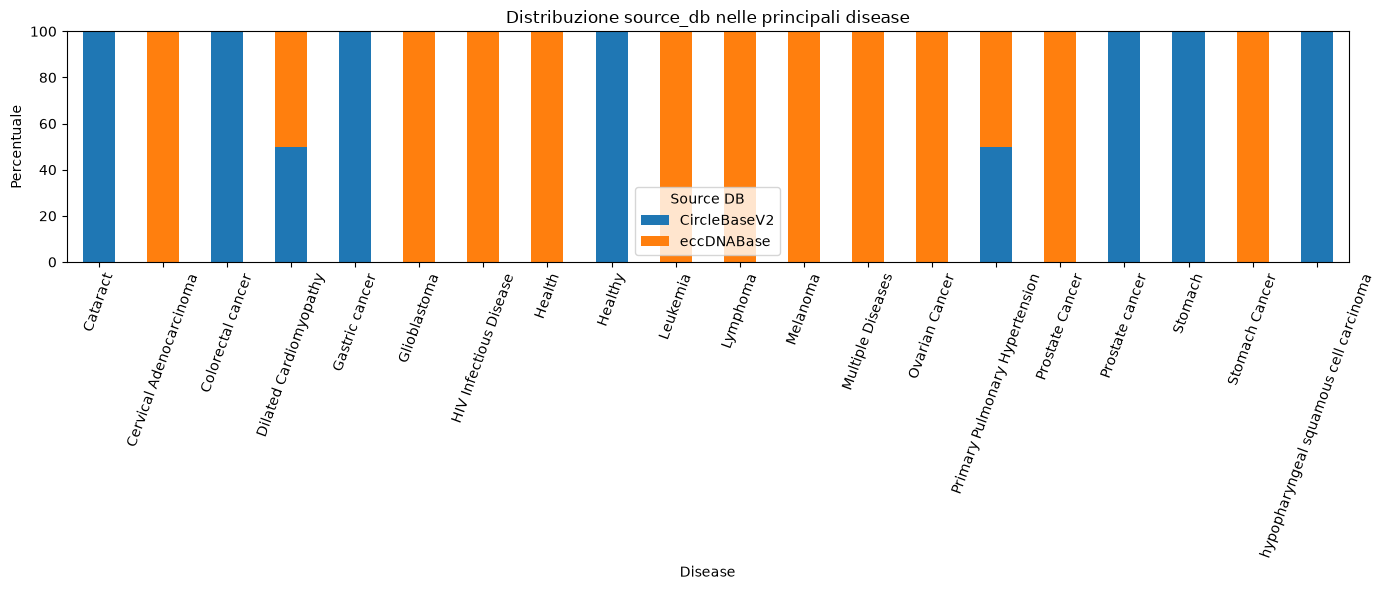

In [37]:
source_top.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.ylabel("Percentuale")
plt.xlabel("Disease")
plt.title("Distribuzione source_db nelle principali disease")
plt.xticks(rotation=70)
plt.legend(title="Source DB")

plt.tight_layout()
plt.show()

disease x tissue

In [38]:
tissues_per_disease = (
    metadata.groupby("disease")["tissue"]
    .nunique()
    .sort_values(ascending=False)
)

tissues_per_disease.head(30)

disease
Health                                   128
Leukemia                                  14
Prostate Cancer                           14
Breast Cancer                             13
Glioblastoma                              12
Lung Cancer                               12
Ovarian Cancer                            11
Brain Cancer                               7
Neuroblastoma                              7
Healthy                                    5
Melanoma                                   5
Colon Cancer                               5
Lymphoma                                   4
Colorectal Cancer                          4
Multiple Myeloma                           4
Coronary Artery Disease                    3
Medulloblastoma                            3
Liver Cancer                               3
Dilated Cardiomyopathy                     2
Kidney Cancer                              2
Gastrointestinal Stromal Tumor             2
Stomach Cancer                             2
Pa

In [39]:
top_diseases = metadata["disease"].value_counts().head(15).index

for disease in top_diseases:

    print("\n" + "=" * 70)
    print(disease)

    counts = (
        metadata.loc[
            metadata["disease"] == disease,
            "tissue"
        ]
        .value_counts(normalize=True)
        .head(10)
        * 100
    )

    print(counts.round(2))


Gastric cancer
tissue
Stomach    100.0
Name: proportion, dtype: float64

Health
tissue
Muscle                                                            56.79
Urine                                                             11.62
Plasma                                                            11.58
Sperm                                                              7.61
Plasma leukocytes                                                  3.45
Control(HCT116, 293A and 293T cells absorbing HaloTag plasmid)     1.64
HEK293                                                             1.57
cardiac                                                            0.92
human adipose stem cells                                           0.85
Testicle                                                           0.66
Name: proportion, dtype: float64

Healthy
tissue
Muscle                  69.93
Subcutaneous Adipose    23.63
Plasma                   4.45
Health                   1.06
Urine                  

disease x lunghezza

In [40]:
length_by_disease = (
    metadata.groupby("disease")["length"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)

length_by_disease.head(20)

,count,mean,median,std,min,max
disease,,,,,,
Gastric cancer,2539762,1022.266325,773.0,1250.640489,100,199832
Health,223896,5398.245141,366.0,18656.473229,50,199872
Healthy,221242,5201.583985,375.0,18368.454691,50,199873
Ovarian Cancer,172434,391.485739,247.0,2950.931327,55,198047
Prostate Cancer,155851,570.587959,326.0,3129.368184,50,199998
Colorectal cancer,86914,892.272603,731.0,648.463870,81,9811
Lymphoma,69245,540.379103,363.0,505.160206,52,86241
Multiple Diseases,57482,593.681692,414.0,545.669685,50,28061
HIV Infectious Disease,42923,869.886471,385.0,6400.898166,53,193246


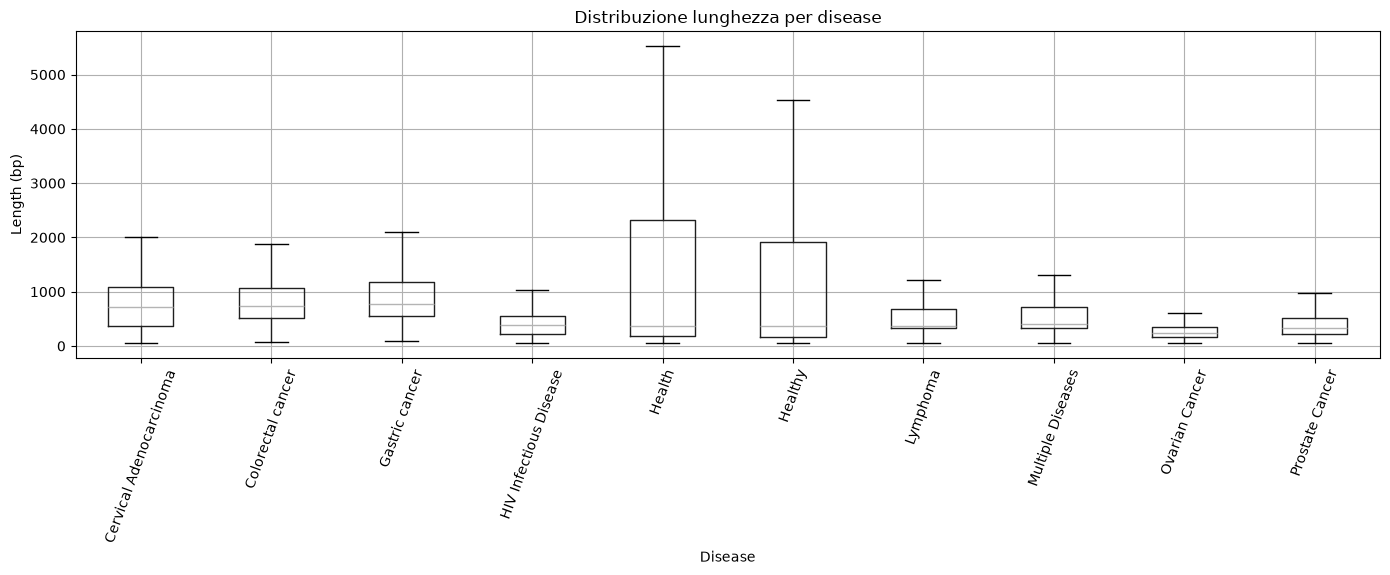

In [41]:
top_diseases = metadata["disease"].value_counts().head(10).index

metadata.loc[
    metadata["disease"].isin(top_diseases)
].boxplot(
    column="length",
    by="disease",
    figsize=(14, 6),
    showfliers=False
)

plt.title("Distribuzione lunghezza per disease")
plt.suptitle("")
plt.xlabel("Disease")
plt.ylabel("Length (bp)")
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

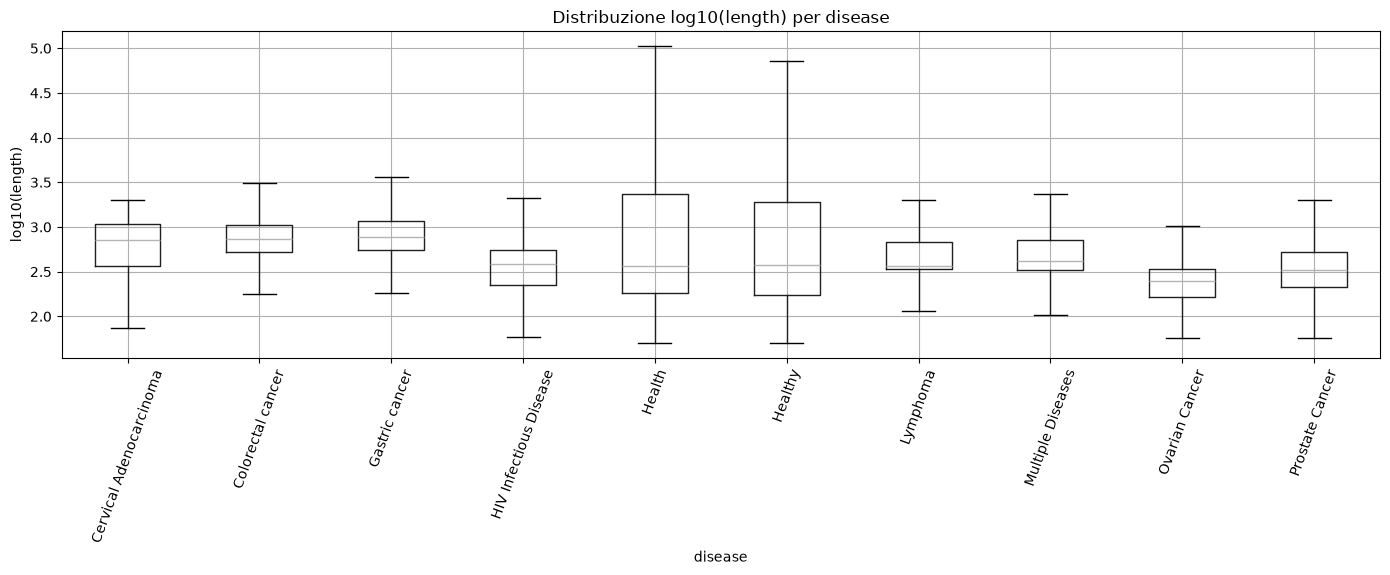

In [42]:
metadata["log_length"] = np.log10(metadata["length"])

metadata.loc[
    metadata["disease"].isin(top_diseases)
].boxplot(
    column="log_length",
    by="disease",
    figsize=(14, 6),
    showfliers=False
)

plt.title("Distribuzione log10(length) per disease")
plt.suptitle("")
plt.xticks(rotation=70)
plt.ylabel("log10(length)")

plt.tight_layout()
plt.show()


Disease x gc content

In [43]:
gc_by_disease = (
    metadata.groupby("disease")["gc"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

gc_by_disease.head(20)

,count,mean,median,std
disease,,,,
Gastric cancer,2539762,0.424185,0.420792,0.062850
Health,223896,0.449082,0.443609,0.093981
Healthy,221242,0.460834,0.460684,0.096116
Ovarian Cancer,172434,0.537890,0.537037,0.058481
Prostate Cancer,155851,0.543634,0.543210,0.073755
Colorectal cancer,86914,0.512614,0.512098,0.078105
Lymphoma,69245,0.536602,0.543103,0.078772
Multiple Diseases,57482,0.439656,0.437089,0.075050
HIV Infectious Disease,42923,0.447748,0.438679,0.088493


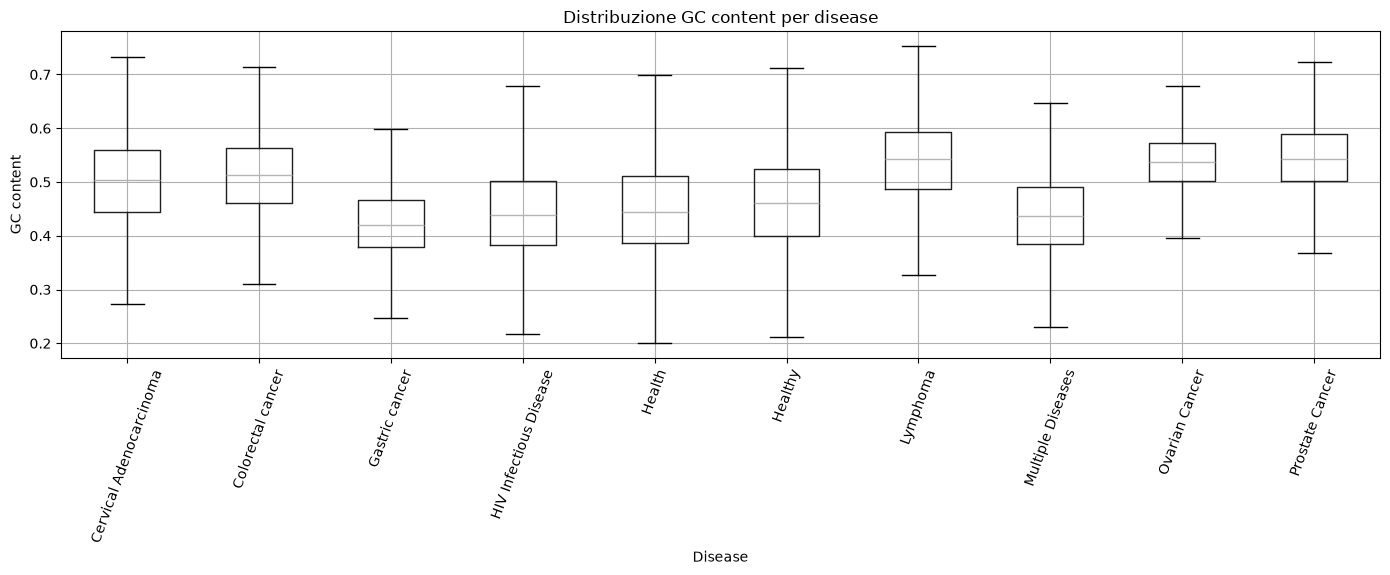

In [44]:
metadata.loc[
    metadata["disease"].isin(top_diseases)
].boxplot(
    column="gc",
    by="disease",
    figsize=(14, 6),
    showfliers=False
)

plt.title("Distribuzione GC content per disease")
plt.suptitle("")
plt.xlabel("Disease")
plt.ylabel("GC content")
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

healtyvs_disease x task bin

In [45]:
pd.crosstab(
    metadata["disease_binary_name"],
    metadata["source_db"],
    normalize="index"
).mul(100).round(2)

source_db,CircleBaseV2,eccDNABase
disease_binary_name,,
disease_associated,81.24,18.76
healthy,49.70,50.30


In [46]:
metadata.groupby("disease_binary_name")["length"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
disease_binary_name,,,,,,
disease_associated,3309941,1082.967912,729.0,4457.783260,50,199998
healthy,445138,5300.500829,370.0,18514.122968,50,199873


In [47]:
metadata.groupby("disease_binary_name")["gc"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
disease_binary_name,,,,
disease_associated,3309941,0.443253,0.435644,0.077735
healthy,445138,0.454923,0.452104,0.095229


## Normalizzazione delle disease

Le etichette originali vengono conservate nella colonna `disease`.

Viene creata una nuova colonna `disease_clean` per uniformare differenze di formattazione e denominazioni equivalenti.

Le equivalenze vengono definite esplicitamente tramite un dizionario, in modo da rendere il preprocessing riproducibile e documentabile.

In [48]:
# Normalizzazione di base delle label

metadata["disease_clean"] = (
    metadata["disease"]
    .astype("string")
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
)


# Alias che consideriamo equivalenti

LABEL_ALIASES = {

    # Healthy
    "health": "healthy",
    "healthy": "healthy",

    # Gastric cancer
    "stomach": "gastric cancer",
    "stomach cancer": "gastric cancer",
    "gastric cancer": "gastric cancer",

    # Glioblastoma
    "glioblastoma": "glioblastoma cancer",
    "glioblastoma cancer": "glioblastoma cancer",
}


metadata["disease_clean"] = (
    metadata["disease_clean"]
    .replace(LABEL_ALIASES)
)

In [49]:
print(
    "Numero classi originali:",
    metadata["disease"].nunique(dropna=True)
)

print(
    "Numero classi normalizzate:",
    metadata["disease_clean"].nunique(dropna=True)
)

display(
    metadata["disease_clean"]
    .value_counts()
    .head(30)
)

Numero classi originali: 73
Numero classi normalizzate: 65


disease_clean
gastric cancer                            2593291
healthy                                    445138
ovarian cancer                             172898
prostate cancer                            170297
colorectal cancer                           88639
lymphoma                                    69245
multiple diseases                           57482
hiv infectious disease                      42923
cervical adenocarcinoma                     38740
leukemia                                    24304
primary pulmonary hypertension               8119
cataract                                     8021
hypopharyngeal squamous cell carcinoma       5925
glioblastoma cancer                          5681
melanoma                                     4787
dilated cardiomyopathy                       3028
hypopharynx cancer                           2450
chronic kidney disease                       2185
branchio-oculo-facial syndrome (bofs)        2076
colorectal adenoma                  

In [50]:
class_counts = metadata["disease_clean"].value_counts()

thresholds = [100, 500, 1000, 5000, 10000]

for threshold in thresholds:

    n_classes = (class_counts >= threshold).sum()

    print(
        f"Classi con almeno {threshold:,} sequenze: "
        f"{n_classes}"
    )

Classi con almeno 100 sequenze: 39
Classi con almeno 500 sequenze: 27
Classi con almeno 1,000 sequenze: 21
Classi con almeno 5,000 sequenze: 14
Classi con almeno 10,000 sequenze: 10


## Raggruppamento descrittivo delle disease

Le disease vengono organizzate in gruppi descrittivi:

- `healthy`
- `cancer`
- `non_cancer_disease`
- `ambiguous`
- `other_unreviewed`

Questo raggruppamento non rappresenta direttamente il target della Siamese Network.

Serve invece a organizzare il dataset senza eliminare le disease non utilizzate nel primo esperimento.

In [51]:
# Classi tumorali già identificate nel dataset

CANCER_CLASSES = {
    "gastric cancer",
    "ovarian cancer",
    "prostate cancer",
    "colorectal cancer",
    "lymphoma",
    "cervical adenocarcinoma",
    "leukemia",
    "hypopharyngeal squamous cell carcinoma",
    "glioblastoma cancer",
    "melanoma",
    "hypopharynx cancer",
    "breast cancer",
    "sarcoma",
    "clear cell renal cell carcinoma",
    "neuroblastoma",
    "smarca4-deficient sarcoma of thorax",
    "esophageal cancer",
    "chordoma",
    "colon cancer",
}


# Patologie non oncologiche già identificate

NON_CANCER_CLASSES = {
    "hiv infectious disease",
    "primary pulmonary hypertension",
    "cataract",
    "dilated cardiomyopathy",
    "chronic kidney disease",
    "branchio-oculo-facial syndrome (bofs)",
    "fetal growth restriction",
    "coronary artery disease",
}


# Label troppo generiche/ambigue

AMBIGUOUS_CLASSES = {
    "multiple diseases",
}

In [52]:
def assign_disease_group(disease):

    if pd.isna(disease):
        return "missing"

    if disease == "healthy":
        return "healthy"

    if disease in CANCER_CLASSES:
        return "cancer"

    if disease in NON_CANCER_CLASSES:
        return "non_cancer_disease"

    if disease in AMBIGUOUS_CLASSES:
        return "ambiguous"

    return "other_unreviewed"


metadata["disease_group"] = (
    metadata["disease_clean"]
    .apply(assign_disease_group)
)

In [53]:
metadata["disease_group"].value_counts()

disease_group
cancer                3180427
healthy                445138
non_cancer_disease      68247
ambiguous               57482
other_unreviewed         3785
Name: count, dtype: int64

In [54]:
pd.crosstab(
    metadata["disease_group"],
    metadata["disease_clean"]
)

disease_clean,b-cell lymphoma,biliary tract cancer,brain cancer,branchio-oculo-facial syndrome (bofs),breast cancer,caid syndrome,cataract,cerebrovascular disease,cervical adenocarcinoma,cervical cancer,...,prostate cancer,sarcoma,skin cancer,smarca4-deficient sarcoma of thorax,systemic lupus erythematosus,thyroid,thyroid cancer,type 2 diabetes mellitus,urinary bladder cancer,uveal melanoma
disease_group,,,,,,,,,,,,,,,,,,,,,
ambiguous,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cancer,0,0,0,0,828,0,0,0,38740,0,...,170297,685,0,506,0,0,0,0,0,0
healthy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
non_cancer_disease,0,0,0,2076,0,0,8021,0,0,0,...,0,0,0,0,0,0,0,0,0,0
other_unreviewed,4,3,21,0,0,202,0,10,0,6,...,0,0,135,0,153,3,3,50,119,3


In [55]:
display(
    metadata[
        [
            "disease_clean",
            "disease_group"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "disease_group",
            "disease_clean"
        ]
    )
)

,disease_clean,disease_group
787,multiple diseases,ambiguous
500,breast cancer,cancer
831,cervical adenocarcinoma,cancer
8820,chordoma,cancer
29313,clear cell renal cell carcinoma,cancer
...,...,...
3173566,thyroid,other_unreviewed
3173567,thyroid cancer,other_unreviewed
899,type 2 diabetes mellitus,other_unreviewed
22224,urinary bladder cancer,other_unreviewed


### Classi numericamente utilizzabili

Il seguente filtro non determina automaticamente quali classi verranno utilizzate dalla Siamese Network.

Serve soltanto a identificare le disease con un numero sufficiente di campioni in train, validation e test.

La selezione delle classi dell'esperimento viene effettuata successivamente sulla base della domanda sperimentale.

In [56]:
split_disease = pd.crosstab(
    metadata["disease_clean"],
    metadata["split_cluster"]
)

split_disease.head()

split_cluster,test,train,val
disease_clean,,,
b-cell lymphoma,1,2,1
biliary tract cancer,0,3,0
brain cancer,1,20,0
branchio-oculo-facial syndrome (bofs),116,1755,205
breast cancer,42,716,70


In [57]:
split_disease = split_disease.sort_values(
    "train",
    ascending=False
)

split_disease.head(30)

split_cluster,test,train,val
disease_clean,,,
gastric cancer,128668,2212052,252571
healthy,20852,381143,43143
ovarian cancer,8355,147776,16767
prostate cancer,8263,145810,16224
colorectal cancer,4422,75706,8511
lymphoma,3409,59060,6776
multiple diseases,2793,48997,5692
hiv infectious disease,2157,36608,4158
cervical adenocarcinoma,1958,33063,3719


In [58]:
eligible_classes = split_disease[
    (split_disease["train"] >= 1000) &
    (split_disease["val"] >= 100) &
    (split_disease["test"] >= 100)
]

eligible_classes

split_cluster,test,train,val
disease_clean,,,
gastric cancer,128668,2212052,252571
healthy,20852,381143,43143
ovarian cancer,8355,147776,16767
prostate cancer,8263,145810,16224
colorectal cancer,4422,75706,8511
lymphoma,3409,59060,6776
multiple diseases,2793,48997,5692
hiv infectious disease,2157,36608,4158
cervical adenocarcinoma,1958,33063,3719


Analisi specifica per k-mer: sparsità teorica

In [59]:
kmer_stats = []

for k in range(4, 11):

    possible_kmers = 4 ** k
    fcgr_size = 2 ** k

    n_kmers = (
        metadata["length"] - k + 1
    ).clip(lower=0)

    median_n_kmers = n_kmers.median()

    # Upper bound teorico:
    # assumiamo, nel caso più favorevole,
    # che tutti i k-mer osservati siano diversi.

    max_unique_kmers = min(
        median_n_kmers,
        possible_kmers
    )

    theoretical_occupancy = (
        max_unique_kmers
        / possible_kmers
        * 100
    )

    kmer_stats.append({
        "k": k,
        "fcgr_size": f"{fcgr_size}x{fcgr_size}",
        "possible_kmers": possible_kmers,
        "median_observed_kmers": median_n_kmers,
        "max_theoretical_occupancy_%":
            theoretical_occupancy
    })


kmer_stats = pd.DataFrame(kmer_stats)

kmer_stats

,k,fcgr_size,possible_kmers,median_observed_kmers,max_theoretical_occupancy_%
0,4,16x16,256,715.0,100.000000
1,5,32x32,1024,714.0,69.726562
2,6,64x64,4096,713.0,17.407227
3,7,128x128,16384,712.0,4.345703
4,8,256x256,65536,711.0,1.084900
5,9,512x512,262144,710.0,0.270844
6,10,1024x1024,1048576,709.0,0.067616


In [60]:
print(
    "Numero classi originali:",
    metadata["disease"].nunique()
)

print(
    "Numero classi normalizzate:",
    metadata["disease_clean"].nunique()
)

metadata["disease_clean"].value_counts().head(20)

Numero classi originali: 73
Numero classi normalizzate: 65


disease_clean
gastric cancer                            2593291
healthy                                    445138
ovarian cancer                             172898
prostate cancer                            170297
colorectal cancer                           88639
lymphoma                                    69245
multiple diseases                           57482
hiv infectious disease                      42923
cervical adenocarcinoma                     38740
leukemia                                    24304
primary pulmonary hypertension               8119
cataract                                     8021
hypopharyngeal squamous cell carcinoma       5925
glioblastoma cancer                          5681
melanoma                                     4787
dilated cardiomyopathy                       3028
hypopharynx cancer                           2450
chronic kidney disease                       2185
branchio-oculo-facial syndrome (bofs)        2076
colorectal adenoma                  

In [61]:
metadata.loc[
    metadata["disease"].str.lower().str.contains(
        "gastric|stomach",
        na=False
    ),
    ["disease", "disease_clean"]
].value_counts()

disease         disease_clean 
Gastric cancer  gastric cancer    2539762
Stomach Cancer  gastric cancer      26834
Stomach         gastric cancer      26695
Name: count, dtype: int64

# Definizione del primo esperimento Siamese

Il dataset completo viene conservato.

Per la prima pipeline end-to-end viene utilizzato un subset costituito da `Healthy` e quattro tipologie tumorali sufficientemente rappresentate in tutti gli split.

Questa selezione rappresenta il primo esperimento e potrà essere successivamente ampliata con ulteriori tumori o patologie non oncologiche.

In [62]:
# Classi da escludere anche se numericamente sufficienti
# perché non rappresentano una singola condizione patologica ben definita.

EXCLUDED_EXPERIMENT_CLASSES = {
    "multiple diseases",
}


# Tutte le classi che superano i requisiti minimi
# definiti precedentemente:
#
# train >= 1000
# val   >= 100
# test  >= 100

EXPERIMENT_CLASSES = [
    disease
    for disease in eligible_classes.index
    if disease not in EXCLUDED_EXPERIMENT_CLASSES
]


print(
    "Numero classi utilizzate:",
    len(EXPERIMENT_CLASSES)
)

for i, disease in enumerate(EXPERIMENT_CLASSES):
    print(f"{i:2d} -> {disease}")

Numero classi utilizzate: 18
 0 -> gastric cancer
 1 -> healthy
 2 -> ovarian cancer
 3 -> prostate cancer
 4 -> colorectal cancer
 5 -> lymphoma
 6 -> hiv infectious disease
 7 -> cervical adenocarcinoma
 8 -> leukemia
 9 -> primary pulmonary hypertension
10 -> cataract
11 -> hypopharyngeal squamous cell carcinoma
12 -> glioblastoma cancer
13 -> melanoma
14 -> dilated cardiomyopathy
15 -> hypopharynx cancer
16 -> chronic kidney disease
17 -> branchio-oculo-facial syndrome (bofs)


In [63]:
class_audit = (
    metadata[
        metadata["disease_clean"].isin(
            EXPERIMENT_CLASSES
        )
    ]
    .groupby(
        [
            "disease_clean",
            "disease_group"
        ]
    )
    .size()
    .reset_index(
        name="n_total"
    )
)


split_counts = (
    pd.crosstab(
        metadata["disease_clean"],
        metadata["split_cluster"]
    )
    .reset_index()
)


class_audit = class_audit.merge(
    split_counts,
    on="disease_clean",
    how="left"
)


class_audit = (
    class_audit
    .sort_values(
        "train",
        ascending=False
    )
    .reset_index(drop=True)
)

class_audit

,disease_clean,disease_group,n_total,test,train,val
0,gastric cancer,cancer,2593291,128668,2212052,252571
1,healthy,healthy,445138,20852,381143,43143
2,ovarian cancer,cancer,172898,8355,147776,16767
3,prostate cancer,cancer,170297,8263,145810,16224
4,colorectal cancer,cancer,88639,4422,75706,8511
5,lymphoma,cancer,69245,3409,59060,6776
6,hiv infectious disease,non_cancer_disease,42923,2157,36608,4158
7,cervical adenocarcinoma,cancer,38740,1958,33063,3719
8,leukemia,cancer,24304,1138,20848,2318
9,primary pulmonary hypertension,non_cancer_disease,8119,384,6987,748


In [64]:
experiment_metadata = metadata[
    metadata["disease_clean"].isin(
        EXPERIMENT_CLASSES
    )
].copy()


print(
    "Numero campioni prima della selezione:",
    f"{len(metadata):,}"
)

print(
    "Numero campioni nelle classi del primo esperimento:",
    f"{len(experiment_metadata):,}"
)

Numero campioni prima della selezione: 3,755,079
Numero campioni nelle classi del primo esperimento: 3,687,747


In [65]:
class_split_counts = pd.crosstab(
    experiment_metadata["disease_clean"],
    experiment_metadata["split_cluster"]
)

class_split_counts

split_cluster,test,train,val
disease_clean,,,
branchio-oculo-facial syndrome (bofs),116,1755,205
cataract,373,6896,752
cervical adenocarcinoma,1958,33063,3719
chronic kidney disease,134,1859,192
colorectal cancer,4422,75706,8511
dilated cardiomyopathy,140,2601,287
gastric cancer,128668,2212052,252571
glioblastoma cancer,296,4880,505
healthy,20852,381143,43143


## Encoding delle classi

Ogni disease utilizzata nel primo esperimento viene associata a un identificativo numerico (`class_id`).

Il mapping viene definito esplicitamente e dovrà rimanere invariato in tutte le fasi successive della pipeline.

In [66]:
CLASS_TO_ID = {
    disease: class_id
    for class_id, disease
    in enumerate(EXPERIMENT_CLASSES)
}

CLASS_TO_ID

{'gastric cancer': 0,
 'healthy': 1,
 'ovarian cancer': 2,
 'prostate cancer': 3,
 'colorectal cancer': 4,
 'lymphoma': 5,
 'hiv infectious disease': 6,
 'cervical adenocarcinoma': 7,
 'leukemia': 8,
 'primary pulmonary hypertension': 9,
 'cataract': 10,
 'hypopharyngeal squamous cell carcinoma': 11,
 'glioblastoma cancer': 12,
 'melanoma': 13,
 'dilated cardiomyopathy': 14,
 'hypopharynx cancer': 15,
 'chronic kidney disease': 16,
 'branchio-oculo-facial syndrome (bofs)': 17}

In [67]:
experiment_metadata["class_id"] = (
    experiment_metadata[
        "disease_clean"
    ]
    .map(CLASS_TO_ID)
)

In [68]:
experiment_metadata[
    [
        "disease_clean",
        "class_id"
    ]
].drop_duplicates().sort_values(
    "class_id"
)

,disease_clean,class_id
3,gastric cancer,0
1,healthy,1
5,ovarian cancer,2
0,prostate cancer,3
23,colorectal cancer,4
685,lymphoma,5
782,hiv infectious disease,6
831,cervical adenocarcinoma,7
214,leukemia,8
80,primary pulmonary hypertension,9


# Downsampling del training set

Il dataset presenta un forte sbilanciamento, soprattutto a causa della numerosità della classe `gastric cancer`.

Seguendo l'indicazione del tutor, viene utilizzato il downsampling anziché l'oversampling.

Il downsampling viene applicato esclusivamente al training set e prima della futura costruzione delle coppie Siamese.

Validation e test vengono mantenuti nella loro distribuzione originale.

In [69]:
MAX_TRAIN_PER_CLASS = 10_000
RANDOM_STATE = 42

In [70]:
def downsample_training_set(
    df,
    classes,
    max_per_class,
    random_state=42
):

    sampled_parts = []

    train_df = df[
        df["split_cluster"] == "train"
    ]

    for class_idx, disease in enumerate(classes):

        class_df = train_df[
            train_df["disease_clean"] == disease
        ]

        n_samples = min(
            len(class_df),
            max_per_class
        )

        sampled = class_df.sample(
            n=n_samples,
            replace=False,
            random_state=(
                random_state
                + class_idx
            )
        )

        sampled_parts.append(sampled)

    return pd.concat(
        sampled_parts,
        ignore_index=True
    )

In [71]:
train_manifest = downsample_training_set(
    experiment_metadata,
    EXPERIMENT_CLASSES,
    MAX_TRAIN_PER_CLASS,
    RANDOM_STATE
)

In [72]:
val_manifest = experiment_metadata[
    experiment_metadata["split_cluster"] == "val"
].copy()


test_manifest = experiment_metadata[
    experiment_metadata["split_cluster"] == "test"
].copy()

In [73]:
print("TRAIN")
display(
    train_manifest[
        "disease_clean"
    ].value_counts()
)

print("\nVALIDATION")
display(
    val_manifest[
        "disease_clean"
    ].value_counts()
)

print("\nTEST")
display(
    test_manifest[
        "disease_clean"
    ].value_counts()
)

TRAIN


disease_clean
gastric cancer                            10000
healthy                                   10000
ovarian cancer                            10000
prostate cancer                           10000
colorectal cancer                         10000
lymphoma                                  10000
hiv infectious disease                    10000
cervical adenocarcinoma                   10000
leukemia                                  10000
primary pulmonary hypertension             6987
cataract                                   6896
hypopharyngeal squamous cell carcinoma     5052
glioblastoma cancer                        4880
melanoma                                   4124
dilated cardiomyopathy                     2601
hypopharynx cancer                         2111
chronic kidney disease                     1859
branchio-oculo-facial syndrome (bofs)      1755
Name: count, dtype: Int64


VALIDATION


disease_clean
gastric cancer                            252571
healthy                                    43143
ovarian cancer                             16767
prostate cancer                            16224
colorectal cancer                           8511
lymphoma                                    6776
hiv infectious disease                      4158
cervical adenocarcinoma                     3719
leukemia                                    2318
cataract                                     752
primary pulmonary hypertension               748
hypopharyngeal squamous cell carcinoma       585
glioblastoma cancer                          505
melanoma                                     438
dilated cardiomyopathy                       287
hypopharynx cancer                           225
branchio-oculo-facial syndrome (bofs)        205
chronic kidney disease                       192
Name: count, dtype: Int64


TEST


disease_clean
gastric cancer                            128668
healthy                                    20852
ovarian cancer                              8355
prostate cancer                             8263
colorectal cancer                           4422
lymphoma                                    3409
hiv infectious disease                      2157
cervical adenocarcinoma                     1958
leukemia                                    1138
primary pulmonary hypertension               384
cataract                                     373
glioblastoma cancer                          296
hypopharyngeal squamous cell carcinoma       288
melanoma                                     225
dilated cardiomyopathy                       140
chronic kidney disease                       134
branchio-oculo-facial syndrome (bofs)        116
hypopharynx cancer                           114
Name: count, dtype: Int64

Manifest finale

In [74]:
siamese_manifest = pd.concat(
    [
        train_manifest,
        val_manifest,
        test_manifest
    ],
    ignore_index=True
)

In [75]:
manifest_counts = pd.crosstab(
    siamese_manifest["disease_clean"],
    siamese_manifest["split_cluster"]
)

manifest_counts

split_cluster,test,train,val
disease_clean,,,
branchio-oculo-facial syndrome (bofs),116,1755,205
cataract,373,6896,752
cervical adenocarcinoma,1958,10000,3719
chronic kidney disease,134,1859,192
colorectal cancer,4422,10000,8511
dilated cardiomyopathy,140,2601,287
gastric cancer,128668,10000,252571
glioblastoma cancer,296,4880,505
healthy,20852,10000,43143


In [76]:
MANIFEST_COLUMNS = [
    "id",
    "disease",
    "disease_clean",
    "disease_group",
    "class_id",
    "split_cluster",
    "cluster_id",
    "length",
    "gc",
    "n_fraction",
    "source_db",
    "tissue",
]

In [77]:
siamese_manifest = (
    siamese_manifest[
        MANIFEST_COLUMNS
    ]
    .copy()
)

In [78]:
print(
    "Shape manifest:",
    siamese_manifest.shape
)

print(
    "ID unici:",
    siamese_manifest["id"].nunique()
)

print(
    "Duplicati:",
    siamese_manifest["id"].duplicated().sum()
)

Shape manifest: (665681, 12)
ID unici: 665681
Duplicati: 0


In [79]:
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [80]:
columns_to_drop = [
    "log_length",
    "n_kmers_k10",
]


metadata_clean = metadata.drop(
    columns=[
        col
        for col in columns_to_drop
        if col in metadata.columns
    ]
).copy()


print(
    "Shape metadata completo pulito:",
    metadata_clean.shape
)

Shape metadata completo pulito: (3755079, 27)


In [81]:
# =========================================================
# 1. DATASET COMPLETO PULITO
# =========================================================

FULL_METADATA_PATH = (
    PROCESSED_DIR
    / "eccdna_metadata_clean.tsv"
)

metadata_clean.to_csv(
    FULL_METADATA_PATH,
    sep="\t",
    index=False
)


# =========================================================
# 2. MANIFEST DEL PRIMO ESPERIMENTO SIAMESE
# =========================================================

SIAMESE_MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_primary_manifest.tsv"
)

siamese_manifest.to_csv(
    SIAMESE_MANIFEST_PATH,
    sep="\t",
    index=False
)


print("Dataset completo salvato:")
print(FULL_METADATA_PATH)

print()
print(
    "Shape dataset completo:",
    metadata_clean.shape
)

print()
print("-" * 80)
print()

print("Manifest Siamese salvato:")
print(SIAMESE_MANIFEST_PATH)

print()
print(
    "Shape manifest Siamese:",
    siamese_manifest.shape
)

Dataset completo salvato:
..\data\processed\eccdna_metadata_clean.tsv

Shape dataset completo: (3755079, 27)

--------------------------------------------------------------------------------

Manifest Siamese salvato:
..\data\processed\siamese_primary_manifest.tsv

Shape manifest Siamese: (665681, 12)


In [82]:
import json

CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "class_mapping.json"
)

with open(
    CLASS_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        CLASS_TO_ID,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Mapping classi salvato:")
print(CLASS_MAPPING_PATH)

Mapping classi salvato:
..\data\processed\class_mapping.json


## Conclusioni della fase di esplorazione e preparazione del dataset

In questa prima fase è stato analizzato il dataset eccDNA con l'obiettivo di comprenderne la struttura, verificarne la qualità e preparare i dati per la successiva generazione delle FCGR e l'addestramento della rete Siamese.

Il dataset originale contiene circa 3,75 milioni di record. I metadati sono contenuti nel file TSV, mentre le sequenze nucleotidiche sono mantenute separatamente nel file FASTA. I due file sono collegati attraverso l'identificativo `id`.

### Normalizzazione delle disease

Le label originali sono state conservate nella colonna `disease`, mentre è stata creata la colonna `disease_clean` per uniformare differenze di formattazione e alcune denominazioni equivalenti.

Le disease sono state inoltre organizzate in gruppi descrittivi (`healthy`, `cancer`, `non_cancer_disease`, `ambiguous` e `other_unreviewed`) senza eliminare le patologie non utilizzate nel primo esperimento.

La categoria `multiple diseases` viene mantenuta nel dataset completo ma considerata ambigua e non utilizzata come classe nel primo esperimento Siamese.

### Analisi dei possibili confondenti

L'analisi ha evidenziato differenze tra le disease nella distribuzione della sorgente (`source_db`), del tessuto, della lunghezza delle sequenze e del GC content.

Questi aspetti dovranno essere considerati nell'interpretazione delle performance del modello, perché potrebbero rappresentare fattori confondenti.

È stata inoltre analizzata la frazione di basi ambigue (`n_fraction`), importante per la futura generazione dei k-mer e delle FCGR.

### Split del dataset

Lo split `split_cluster` originale è stato mantenuto come riferimento per train, validation e test.

Lo split viene effettuato a livello di sample prima della futura costruzione delle coppie Siamese, evitando quindi che uno stesso campione possa comparire contemporaneamente nel training e nel test attraverso coppie differenti.

È stata inoltre verificata la relazione tra `cluster_id` e `split_cluster` per identificare eventuali cluster presenti in più split.

### Primo esperimento Siamese

Per il primo esperimento vengono utilizzate 18 classi sufficientemente
rappresentate negli split train, validation e test.

Le classi comprendono `Healthy`, differenti patologie oncologiche e alcune
patologie non oncologiche.

La categoria `multiple diseases`, pur essendo numericamente ben rappresentata,
viene esclusa perché non identifica una singola condizione patologica e non
permetterebbe di definire in modo affidabile le coppie positive della Siamese Network.

Ad ogni classe è stato assegnato un identificativo numerico `class_id`.

Seguendo l'indicazione di gestire lo sbilanciamento tramite downsampling,
il training set è stato limitato a un massimo di 10.000 campioni per classe.
Le classi che possiedono meno di 10.000 campioni vengono invece mantenute
integralmente.

Validation e test conservano la distribuzione originale.

Il downsampling viene quindi effettuato prima della futura generazione delle
coppie positive e negative.

### Analisi preliminare dei k-mer

Sono stati considerati valori di k compresi tra 4 e 10.

L'analisi teorica mostra che aumentando k cresce rapidamente il numero di k-mer possibili e la dimensione della FCGR, mentre diminuisce la frazione della matrice che una singola sequenza può occupare.

La sparsità reale verrà misurata nella fase successiva durante la generazione delle FCGR.

### Output

Sono stati prodotti due file:

1. `eccdna_metadata_clean.tsv`, contenente il dataset completo con le label normalizzate e le informazioni descrittive;
2. `siamese_primary_manifest.tsv`, contenente i campioni selezionati per il primo esperimento Siamese.

La fase successiva sarà dedicata all'estrazione delle sequenze FASTA corrispondenti ai sample del manifest e alla generazione e analisi delle FCGR per k compreso tra 4 e 10.